In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
## scipy library
from scipy import fftpack
from scipy import signal
import scipy.io.wavfile
from scipy import io



In [4]:
def simulated_signal(t):
    """ returns a simulated signal """
    return ( 2* np.sin(1* 2 * np.pi * t) + 3* np.sin(22* 2 * np.pi * t) + 3* np.random.randn(*np.shape(t)))

In [5]:
np.random.seed(0)


In [6]:
B=30
f_s = 2*B
delta_f = 0.01
N = int(f_s/ delta_f)
T = N/ f_s


In [7]:
time_vector = np.linspace(0, T, N)
time_vector.shape

(6000,)

In [8]:
samples = simulated_signal(time_vector)
samples.shape

(6000,)

  ### Visualizing Simulated Signal with random Noise
  - The plot on the left hand side displays the signal over the entire sampling time
  - The plot on the right handside displays the signal within a time window of $0s - 5s$

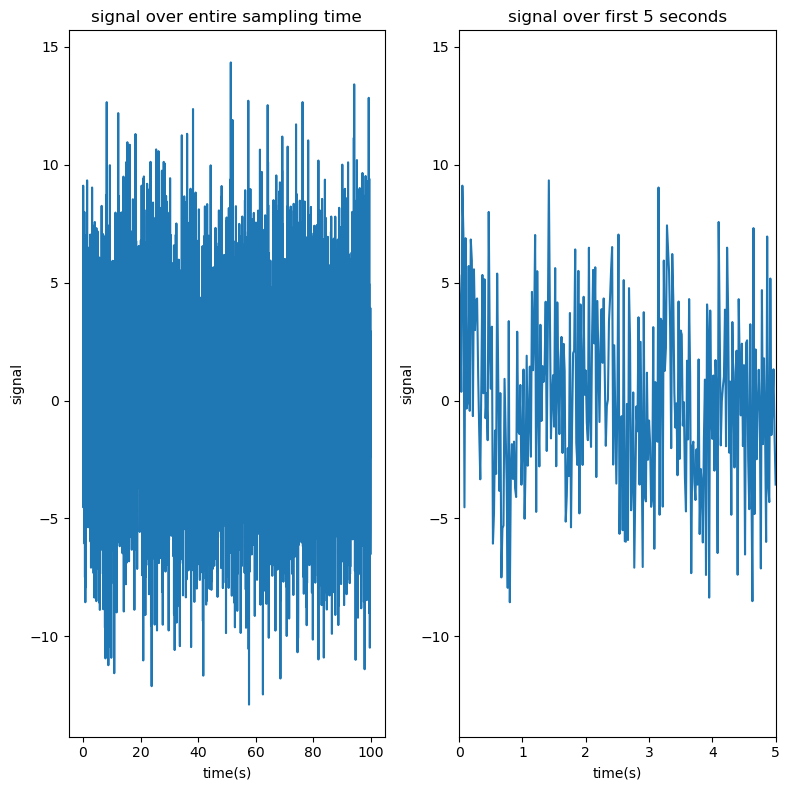

In [9]:
fig, ax =plt.subplots(nrows=1, ncols=2, figsize=(8, 8))
ax[0].plot(time_vector, samples)
ax[0].set_xlabel("time(s)")
ax[0].set_ylabel("signal")
ax[0].set_title("signal over entire sampling time")
ax[1].plot(time_vector, samples)
ax[1].set_xlim([0, 5])
ax[1].set_xlabel("time(s)")
ax[1].set_ylabel("signal")
ax[1].set_title("signal over first 5 seconds")
fig.tight_layout()
fig.savefig("simulated signal")


### Application of Fourier Transforms
- `F = fftpack.fft(samples)`
- The FFT asks How much 0 `Hz?` `1 Hz?` `2 Hz?` `3 Hz?` ...`30 Hz?` exists in the signal?

- The FFT computes $$ X_k = \sum_{n=0}^{N-1} x_ne^{\frac{-i2\pi nk}{N}}$$
- F is a vector that stores `F[0]`, `F[1]`, `F[2]`, ...,`F[5999]` Each element corresponds to a frequency bin.Each value is a complex number, containing both the `amplitude` and     `phase` of that frequency component.
- in a nutshel it contains the amplitude of vibration at each frequency

In [27]:
F = fftpack.fft(samples)
F

array([-278.05051476  -0.j        ,   96.47197576+126.53730599j,
       -291.93011608 +59.15757212j, ...,  -42.66812026-218.70051533j,
       -291.93011608 -59.15757212j,   96.47197576-126.53730599j],
      shape=(6000,))

### Finding the Actual Frequencies
 - `freq =fftfreq(N,1.0/f_s)`
 - The FFT only tells us `Bin 0` , `Bin 1`, `Bin 2`, ... 
- But we want `0 Hz` , `0.01 Hz`, `0.02 Hz`, ...
- fftfreq() converts bin numbers into real frequencies using the sampling interval and the total number of samples.

In [ ]:
freq = fftpack.fftfreq(N, 1/f_s)
freq

array([ 0.  ,  0.01,  0.02, ..., -0.03, -0.02, -0.01], shape=(6000,))

In [12]:
mask = np.where( freq >= 0)
mask

(array([   0,    1,    2, ..., 2997, 2998, 2999], shape=(3000,)),)

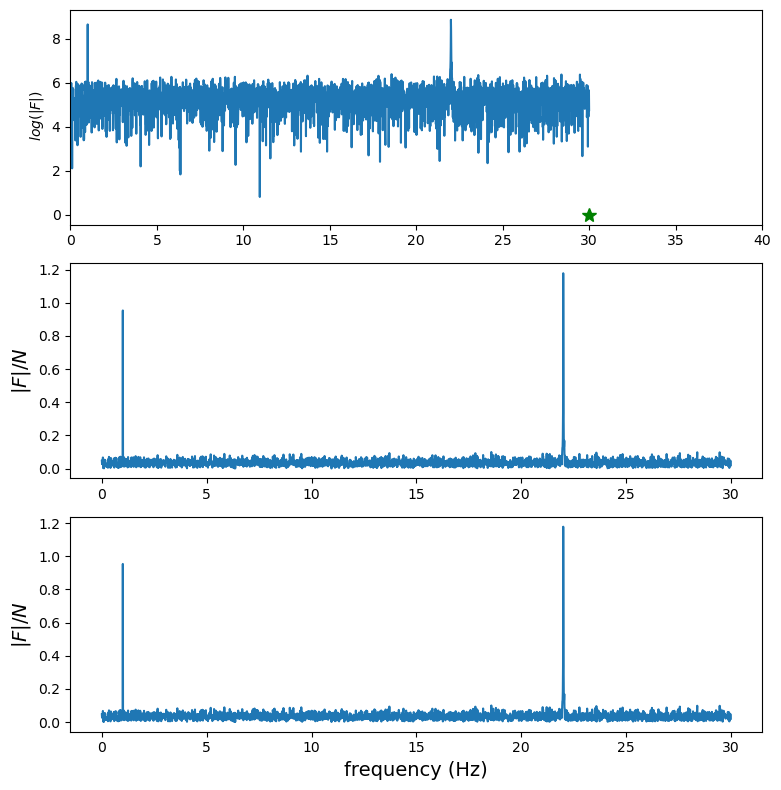

In [28]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(8, 8))
ax[0].plot(freq[mask], np.log(abs(F[mask])))
ax[0].plot(B, 0, 'g*', markersize=10)
ax[0].set_xlim(0, 40)
ax[0].set_ylabel("$\ log(|F|)$")

ax[1].plot(freq[mask], abs(F[mask])/N)
ax[1].set_ylabel("$|F|/N$", fontsize=14)

ax[2].plot(freq[mask], abs(F[mask])/N)
ax[2].set_xlabel("frequency (Hz)", fontsize=14)
ax[2].set_ylabel("$|F|/N$", fontsize=14)
fig.tight_layout()
fig.savefig("simulated-signal-spectrum.png")

